In [1]:
from utils_00 import *
# exec(open('c00_utils.py').read())

pn.extension()  # 启用 Jupyter 支持
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
native_exchange_data_dir = os.path.join(base_dir, "Native_Exchange_Data")
temporary_experimental_data_dir = os.path.join(base_dir, "Temporary_Experimental_Data")
pro = ts.pro_api(secret_dict['tushare']['api_key'])

def get_exchange_variety_map():
    # 交易所日历路径 NED_dimension_exchange_calendar_path
    NED_dimension_exchange_calendar_path = os.path.join(native_exchange_data_dir, 'dimension_exchange_calendar.csv')
    dimension_exchange_calendar = pd.read_csv(NED_dimension_exchange_calendar_path, dtype = {'date': str})

    # 获取 交易所-品种 表单
    exchange_list = [col for col in dimension_exchange_calendar.columns if col != 'date'] # 交易所列表
    map_list = []
    for exchange in exchange_list:

        exchange_variety_map = pd.DataFrame()
        for attempt in range(3):
            try:
                exchange_variety_map = pro.fut_basic(exchange = exchange, fut_type = "1", fields = ["fut_code"])
                break
            except Exception as e:
                print(f"第 {attempt + 1} 次获取 {exchange} 品种信息失败: {e}")

        exchange_variety_map = exchange_variety_map.drop_duplicates()
        exchange_variety_map["exchange"] = exchange
        map_list.append(exchange_variety_map)

    exchange_variety_map = pd.concat(map_list, ignore_index = True)
    exchange_variety_map = exchange_variety_map.groupby('exchange')['fut_code'].apply(list)
    exchange_variety_map = exchange_variety_map.to_dict()
    return exchange_variety_map

if __name__ == '__main__':
    exchange_variety_map = get_exchange_variety_map()
    exchange_variety_map.pop("CZCE")
    exchange_variety_map.pop("DCE")
    print(exchange_variety_map)

{'CFFEX': ['T', 'TF', 'IF', 'IM', 'IC', 'IH', 'TS', 'TL'], 'GFEX': ['LC', 'SI', 'PS', 'PD', 'PT'], 'INE': ['NR', 'SC', 'LU', 'BC', 'SCTAS', 'EC'], 'SHFE': ['AO', 'NI', 'AL', 'HC', 'BU', 'RU', 'FU', 'CU', 'AG', 'ZN', 'AU', 'PB', 'SS', 'RB', 'SN', 'WR', 'SP', 'BR', 'AD', 'OP']}


In [3]:
exchange = None
variety = None

if __name__ == '__main__':
    # 交易所选择组件
    exchange_radio = widgets.RadioButtons(
        options = list(exchange_variety_map.keys()),
        description = '交易所选择 exchange:',
        layout = {'width': '400px'}
    )

    # 品种选择组件（初始禁用）
    species_toggle = widgets.ToggleButtons(
        options = [],
        description = '品种选择 variety:',
        disabled = True,
        button_style = '',
        style = {'button_width': 'auto'},
        layout = widgets.Layout(width = '600px'),
    )

    # 输出提示区域
    out = widgets.Textarea(
        value = '请先选择交易所，然后选择品种',
        layout = {'width': '400px', 'height': '50px'},
        disabled = True
    )

    display(widgets.VBox([exchange_radio, species_toggle, out]))

    def on_exchange_change(change):
        """当交易所改变时，更新可选品种"""
        global exchange
        if change['name'] == 'value':
            exchange = change['new']
            varieties = exchange_variety_map.get(exchange, [])
            species_toggle.options = sorted(varieties)
            species_toggle.disabled = len(varieties) == 0
            if varieties:
                species_toggle.value = varieties[0]  # 默认选第一个
                out.value = f'已选择交易所：{exchange}，请选择品种'
            else:
                out.value = f'交易所 {exchange} 无可用品种'

    def on_species_change(change):
        """当品种改变时，记录到全局变量"""
        global variety
        if change['name'] == 'value' and species_toggle.options:
            variety = change['new']
            out.value = f'已选择交易所 exchange: {exchange}\n已选择品种 variety: {variety}'

    # 绑定事件 ["SCTAS", "SI", "FU", "AU", "SS", "WR"]
    exchange_radio.observe(on_exchange_change, names = 'value')
    species_toggle.observe(on_species_change, names = 'value')

In [4]:
dataset_range_boundary = ""  # 选择的时间范围边界字符串

if __name__ == '__main__':

    # 临时实验数据品种文件夹路径 TED_variety_path
    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))
    dataset_range = os.listdir(TED_variety_path)
    dataset_range = sorted(dataset_range)

    dataset_range_buttons = []  # 创建数据集范围边界按钮容器
    for range_file in dataset_range:  # 为每个范围文件创建按钮
        btn = widgets.Button(
            description = range_file,
            layout = {'width': '530px', 'height': '25px'},  # 宽度较大以显示完整文件名
            button_style = ''
        )
        dataset_range_buttons.append(btn)

    dataset_range_button_column = widgets.VBox(dataset_range_buttons) # Horizontal Box & Vertical Box

    # 输出显示区域
    range_display_output = widgets.Textarea(
        value = 'dataset_range_boundary: 未选择',
        layout = {'width': '530px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([
        widgets.Label('数据集范围边界 dataset_range_boundary:'),
        dataset_range_button_column,
        range_display_output
    ]))

    def update_range_display():
        """更新显示区域"""
        global dataset_range_boundary
        range_display_output.value = f'dataset_range_boundary: {dataset_range_boundary}'

    def set_dataset_range_boundary(range_file):
        """设置数据集范围边界"""
        global dataset_range_boundary
        dataset_range_boundary = range_file
        update_range_display()

    # 事件处理函数
    def on_dataset_range_button_click(btn):
        """数据集范围按钮 点击事件"""
        set_dataset_range_boundary(btn.description)

    # 绑定事件
    for btn in dataset_range_buttons:
        btn.on_click(on_dataset_range_button_click)

    # 初始化
    update_range_display()

In [5]:
tick_granularity = 0  # 采样颗粒度 全局变量
resample_axis = None  # 采样轴 全局变量

if __name__ == '__main__':

    # 创建 tick_granularity 输入框组件
    tick_granularity_input = widgets.IntText(
        value = 0,
        description = 'tick_granularity:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '90px'},
        continuous_update = False
    )

    # 创建 tick_granularity 按钮容器
    granularity_buttons = []
    for i in [i for i in range(0, 181, 15)]:
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        granularity_buttons.append(btn)
    granularity_button_row = widgets.HBox(granularity_buttons)

    # tick_granularity 输出显示区域
    granularity_out = widgets.Textarea(
        value = '当前 tick_granularity: 0',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 创建 resample_axis 按钮
    axis_buttons = []
    axis_options = ['time_axis_data', 'volume_axis_data', 'money_axis_data']  # 重采样刻度选项
    for option in axis_options:
        btn = widgets.Button(
            description = option,
            layout = {'width': '135px', 'height': '25px'}
        )
        btn.value = option
        axis_buttons.append(btn)
    axis_button_row = widgets.HBox(axis_buttons)

    # resample_axis 显示区域
    axis_out = widgets.Textarea(
        value = '当前 resample_axis: None',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([tick_granularity_input, granularity_button_row, granularity_out, axis_button_row, axis_out]))

    def update_display(value):
        """更新显示"""
        global tick_granularity
        tick_granularity = value
        granularity_out.value = f'当前 tick_granularity: {tick_granularity}'
        tick_granularity_input.value = value

    def update_axis_display(value):
        """更新 resample_axis 显示"""
        global resample_axis
        resample_axis = value
        axis_out.value = f'当前 resample_axis: {resample_axis}'

    def on_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 600:
                update_display(new_value)
            else:
                tick_granularity_input.value = tick_granularity  # 恢复原值

    def on_button_click(btn):
        """当按钮点击时"""
        new_value = btn.value
        update_display(new_value)

    def on_axis_button_click(btn):
        """当 resample_axis 按钮点击时"""
        new_value = btn.value
        update_axis_display(new_value)

    # 绑定输入框事件
    tick_granularity_input.observe(on_input_change, names ='value')

    # 绑定所有按钮事件
    for btn in granularity_buttons:
        btn.on_click(on_button_click)

    # 绑定 resample_axis 按钮事件
    for btn in axis_buttons:
        btn.on_click(on_axis_button_click)

In [6]:
lookback_months = 0  # 回溯月份数 全局变量
split_index = None  # 切割点 index 全局变量
split_time_str = None  # 切割时间字符串 全局变量

if __name__ == '__main__':

    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))  # 临时实验数据品种文件夹路径 TED_variety_path
    dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)  # 时间范围文件夹路径 dataset_range_boundary_path
    tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')  # 采样刻度文件路径 tick_granularity_resample_path
    resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)  # 驱动轴数据文件路径 resample_axis_data_path

    tick_type_dict = {
        'time_axis_data': 'Nrow',
        'volume_axis_data': 'volume',
        'money_axis_data': 'money'
    }
    if resample_axis in tick_type_dict.keys():
        tick_type = tick_type_dict[resample_axis]
    else: raise ValueError

    # 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
    main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, rf"main_continuous_{tick_type}_date_index.csv")
    main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

    # 创建 lookback_months 输入框组件
    lookback_months_input = widgets.IntText(
        value = 0,
        description = 'lookback_months:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '100px'},
        continuous_update = False
    )

    # 创建 lookback_months 按钮容器（1~24）
    months_buttons = []
    for i in range(1, 25):
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        months_buttons.append(btn)
    first_row = widgets.HBox(months_buttons[:12])   # 前12个按钮
    second_row = widgets.HBox(months_buttons[12:])  # 后12个按钮
    months_button_row = widgets.VBox([first_row, second_row])

    # 输出显示区域：包含回溯月份、切割index、切割时间
    split_info_out = widgets.Textarea(
        value = '当前 lookback_months: \nsplit_index: None \nsplit_time_str: None',
        layout = {'width': '600px', 'height': '60px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([lookback_months_input, months_button_row, split_info_out]))

    def update_split_info():
        """根据 lookback_months 和 main_continuous_resampled_date_index 计算并更新 split_index 与 split_time_str"""
        global lookback_months, split_index, split_time_str

        if lookback_months <= 0 or main_continuous_resampled_date_index.empty:
            split_index = None
            split_time_str = None
        else:
            # 获取最后一行的时间字符串并转换为 datetime
            last_time_str = main_continuous_resampled_date_index['date'].iloc[-1]
            last_dt = pd.to_datetime(last_time_str)

            # 回溯指定月份数（注意：pandas 的 DateOffset 支持月份偏移）
            target_dt = last_dt - pd.DateOffset(months=lookback_months)

            # 找到最接近但不大于 target_dt 的行的 index
            date_series = pd.to_datetime(main_continuous_resampled_date_index['date'])
            valid_mask = date_series <= target_dt
            if valid_mask.any():
                split_index = valid_mask[::-1].idxmax()  # 最后一个满足条件的 index
                split_time_str = main_continuous_resampled_date_index['date'].iloc[split_index]
            else:
                split_index = 0
                split_time_str = main_continuous_resampled_date_index['date'].iloc[0]

        # 更新显示
        split_info_out.value = f'当前 lookback_months: {lookback_months} \nsplit_index: {split_index} \nsplit_time_str: {split_time_str}'

    def on_months_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 24:
                global lookback_months
                lookback_months = new_value
                lookback_months_input.value = new_value
                update_split_info()
            else:
                lookback_months_input.value = lookback_months  # 恢复原值

    def on_months_button_click(btn):
        """当按钮点击时"""
        global lookback_months
        lookback_months = btn.value
        lookback_months_input.value = lookback_months
        update_split_info()

    # 绑定输入框事件
    lookback_months_input.observe(on_months_input_change, names='value')

    # 绑定所有按钮事件
    for btn in months_buttons:
        btn.on_click(on_months_button_click)

    # 初始化显示
    update_split_info()

In [7]:
# 临时实验数据品种文件夹路径 TED_variety_path
TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))

# 时间范围文件夹路径 dataset_range_boundary_path
dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)

# 采样刻度文件路径 tick_granularity_resample_path
tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')

# 驱动轴数据文件路径 resample_axis_data_path
resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)



tick_type_dict = {
    'time_axis_data': 'Nrow',
    'volume_axis_data': 'volume',
    'money_axis_data': 'money'
}
if resample_axis in tick_type_dict.keys():
    tick_type = tick_type_dict[resample_axis]
else: raise ValueError

# 主力片段拼接重采样序列文件路径 main_continuous_resampled_timeseries_path
main_continuous_resampled_timeseries_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_timeseries.csv')
main_continuous_resampled_timeseries = pd.read_csv(main_continuous_resampled_timeseries_path, dtype = {'date': str})

# 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_timeseries.csv')
main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

# 时间序列特征文件夹路径 TS_dynamic_metrics_path
TS_dynamic_metrics_path = os.path.join(resample_axis_data_path, f'TS_dynamic_metrics')
os.makedirs(TS_dynamic_metrics_path, exist_ok = True)

### 1. NSS 衍生价格序列

In [8]:
# 期限结构拟合文件路径 Nelson_Siegel_Svensson_path
Nelson_Siegel_Svensson_path = os.path.join(resample_axis_data_path, f'Nelson_Siegel_Svensson')

# NSS 四因子模型参数路径 NSS_factors_path
NSS_factors_path = os.path.join(Nelson_Siegel_Svensson_path, f'NSS_factors.csv')
NSS_factors = pd.read_csv(NSS_factors_path)
# NSS_factors.info()
# print('print(NSS_factors.head())')
# print(NSS_factors.head())

# 主力连续期限结构开盘价路径 main_continuous_curve_structure_open_timeseries_path
main_continuous_curve_structure_open_timeseries_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_open_timeseries.csv")
main_continuous_curve_structure_open_timeseries = pd.read_csv(main_continuous_curve_structure_open_timeseries_path, dtype = {'date': str})
# main_continuous_curve_structure_open_timeseries.info()
# print('print(main_continuous_curve_structure_open_timeseries.head())')
# print(main_continuous_curve_structure_open_timeseries.head())

# 主力连续重采样位置分布表格路径 main_continuous_curve_structure_position_timeseries_path
main_continuous_curve_structure_position_timeseries_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_position_timeseries.csv")
main_continuous_curve_structure_position_timeseries = pd.read_csv(main_continuous_curve_structure_position_timeseries_path, dtype = {'date': str})
# main_continuous_curve_structure_position_timeseries.info()
# print('print(main_continuous_curve_structure_position_timeseries.head())')
# print(main_continuous_curve_structure_position_timeseries.head())

# 主力连续期限结构到期时间路径 main_continuous_curve_structure_time_length_path
main_continuous_curve_structure_time_length_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_time_length.csv")
main_continuous_curve_structure_time_length = pd.read_csv(main_continuous_curve_structure_time_length_path, dtype = {'date': str})
# main_continuous_curve_structure_time_length.info()
# print('print(main_continuous_curve_structure_time_length.head())')
# print(main_continuous_curve_structure_time_length.head())



position_matrix = main_continuous_curve_structure_position_timeseries.drop(columns=['date']) # 丢弃 date 列方便后续提取位置掩码
maturity_matrix = main_continuous_curve_structure_time_length.drop(columns = ['date']) # 丢弃 date 列方便后续提取时间行
maturity_matrix = maturity_matrix / (24 * 60)  # 将剩余到期时间从分钟转换为 天

In [9]:
def compute_nss_prices_from_maturities(
    NSS_factors: pd.DataFrame,
    maturities: np.ndarray
) -> np.ndarray:
    """ NSS 计算的核心封装函数

    parameter:
        NSS_factors: 包含 lambda_1, lambda_2, beta_0~3 的 DataFrame
        maturities: 指定天数的序列 (n_rows,)

    return: prices: 价格序列 (n_rows,) """

    n_rows = len(NSS_factors)
    prices = np.zeros(n_rows)

    for idx in range(n_rows):
        row = NSS_factors.iloc[idx]
        lambda_1 = row['lambda_1']
        lambda_2 = row['lambda_2']
        beta = np.array([row['beta_0'], row['beta_1'], row['beta_2'], row['beta_3']])
        tau = maturities[idx]

        # 避免除零
        if tau < 1e-3:
            prices[idx] = beta[0] + beta[1]
            continue

        # NSS 价格载荷公式（与 compute_nss_fitted_price 一致）
        L0 = 1.0
        L1 = (1 - np.exp(-lambda_1 * tau)) / (lambda_1 * tau)
        L2 = L1 - np.exp(-lambda_1 * tau)
        L3 = (1 - np.exp(-lambda_2 * tau)) / (lambda_2 * tau) - np.exp(-lambda_2 * tau)

        # 直接计算价格
        prices[idx] = beta[0] * L0 + beta[1] * L1 + beta[2] * L2 + beta[3] * L3

    return prices

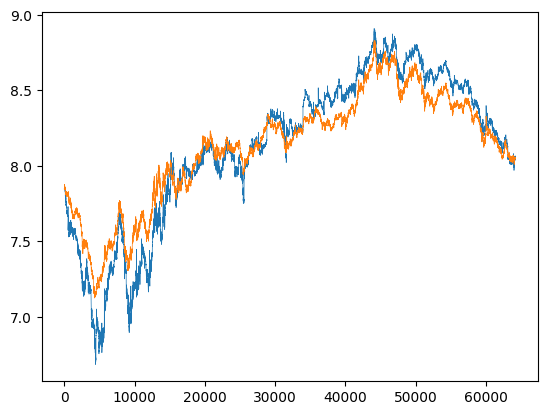

In [10]:
def _calc_near_month_prices():

    # 15 日到期近月理论价格序列
    target_near_days = 15
    n_rows = len(NSS_factors)

    near_month_prices = compute_nss_prices_from_maturities(
        NSS_factors = NSS_factors,
        maturities = np.full(n_rows, target_near_days) )
    near_month_prices = np.log(near_month_prices)

    pd.Series(near_month_prices).plot(lw = 0.5)
    np.log(main_continuous_resampled_timeseries['close']).plot(lw = 0.5)

    return near_month_prices

near_month_prices = _calc_near_month_prices()

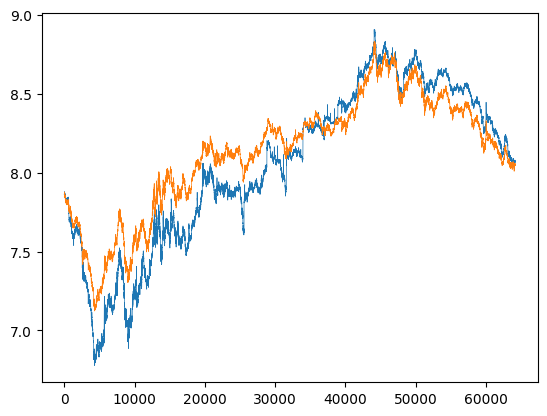

In [11]:
def _calc_far_month_prices():

    # 最远到期日倒数 15 天远月理论价格序列
    target_far_days = 15
    n_rows = len(NSS_factors)

    max_maturity = np.max(maturity_matrix)
    fixed_far_maturities = np.full(n_rows, max_maturity - target_far_days)

    far_month_prices = compute_nss_prices_from_maturities(
        NSS_factors = NSS_factors,
        maturities = fixed_far_maturities )
    far_month_prices = np.log(far_month_prices)

    pd.Series(far_month_prices).plot(lw = 0.5)
    np.log(main_continuous_resampled_timeseries['close']).plot(lw = 0.5)
    return far_month_prices

far_month_prices = _calc_far_month_prices()

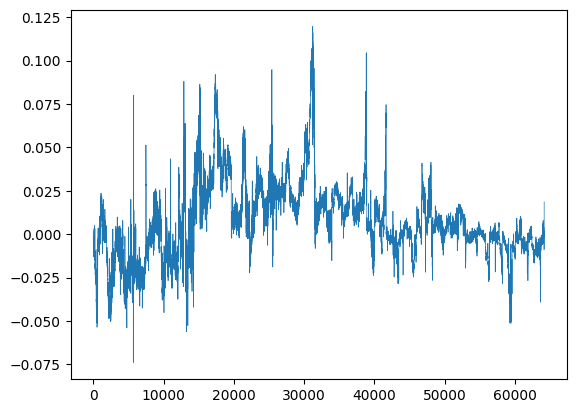

In [12]:
def _calc_near_main_near_prices():

    # 计力近端价格序列，即主力合约的前一个合约
    n_rows = len(NSS_factors)
    near_main_near_maturities = np.zeros(n_rows)
    main_contract_indices = np.zeros(n_rows, dtype = int)

    for idx in range(n_rows):
        maturity_row = maturity_matrix.iloc[idx, :].values
        position_row = position_matrix.iloc[idx, :].values

        # 找到主力合约索引
        main_idx = np.where(position_row == 1)[0]
        main_idx = main_idx[0] if len(main_idx) > 0 else 0
        main_contract_indices[idx] = main_idx

        # 主力近端：前一个合约（最小为0）
        near_main_near_idx = max(0, main_idx - 1)
        near_main_near_maturities[idx] = maturity_row[near_main_near_idx]

    near_main_near_prices = compute_nss_prices_from_maturities(
        NSS_factors = NSS_factors,
        maturities = near_main_near_maturities )



    n_rows = len(main_continuous_curve_structure_position_timeseries)
    main_prices = np.zeros(n_rows)
    for idx in range(n_rows):
        position_row = main_continuous_curve_structure_position_timeseries.iloc[idx, 1:].values  # 跳过date列
        open_row = main_continuous_curve_structure_open_timeseries.iloc[idx, 1:].values          # 跳过date列

        main_idx = np.where(position_row == 1)[0] # 找到主力合约索引（position 为 1 的列）
        main_idx = main_idx[0] if len(main_idx) > 0 else 0
        main_prices[idx] = open_row[main_idx] # 提取主力价格

    near_main_near_spread = np.log(near_main_near_prices) - np.log(main_prices)
    pd.Series(near_main_near_spread).plot(lw = 0.5)
    return near_main_near_spread

near_main_near_spread = _calc_near_main_near_prices()

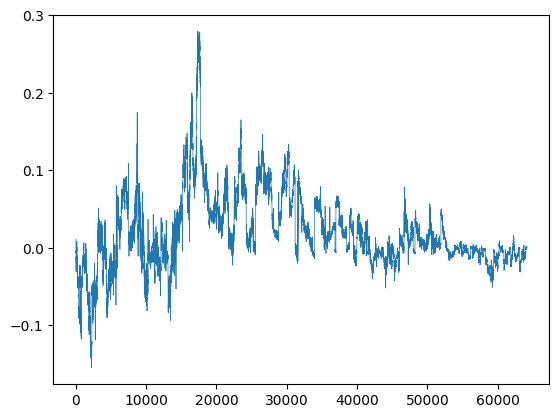

In [13]:
def _calc_near_main_far_prices():

    # 计算主力远端价格序列，即主力合约的后一个合约
    n_rows = len(NSS_factors)
    main_contract_indices = np.zeros(n_rows, dtype = int)

    n_contracts = 13  # 合约总数上限
    near_main_far_maturities = np.zeros(n_rows)
    near_main_far_indices = np.zeros(n_rows, dtype = int)

    for idx in range(n_rows):
        maturity_row = maturity_matrix.iloc[idx, :].values
        main_idx = main_contract_indices[idx]

        # 主力远端：后一个合约（最大为 n_contracts-1）
        near_main_far_idx = min(n_contracts - 1, main_idx + 1)
        near_main_far_maturities[idx] = maturity_row[near_main_far_idx]
        near_main_far_indices[idx] = near_main_far_idx

    near_main_far_prices = compute_nss_prices_from_maturities(
        NSS_factors = NSS_factors,
        maturities = near_main_far_maturities )



    n_rows = len(main_continuous_curve_structure_position_timeseries)
    main_prices = np.zeros(n_rows)
    for idx in range(n_rows):
        position_row = main_continuous_curve_structure_position_timeseries.iloc[idx, 1:].values  # 跳过date列
        open_row = main_continuous_curve_structure_open_timeseries.iloc[idx, 1:].values          # 跳过date列

        main_idx = np.where(position_row == 1)[0] # 找到主力合约索引（position 为 1 的列）
        main_idx = main_idx[0] if len(main_idx) > 0 else 0
        main_prices[idx] = open_row[main_idx] # 提取主力价格

    near_main_far_spread = np.log(near_main_far_prices) - np.log(main_prices)
    pd.Series(near_main_far_spread).plot(lw = 0.5)
    return near_main_far_spread

near_main_far_spread = _calc_near_main_far_prices()

In [14]:
NSS_derived_basis_price = pd.DataFrame({
    'near_month_price': near_month_prices,
    'far_month_price': far_month_prices,
    'near_main_near_spread': near_main_near_spread,
    'near_main_far_spread': near_main_far_spread
})


for var_name in [
    'main_continuous_curve_structure_open_timeseries',
    'main_continuous_curve_structure_position_timeseries',
    'main_continuous_curve_structure_time_length',
]:
    if var_name in locals(): del locals()[var_name]

for var_name in [
    'position_matrix',
    'maturity_matrix',
]:
    if var_name in locals(): del locals()[var_name]

import gc; gc.collect()
NSS_derived_basis_price.head()

,near_month_price,far_month_price,near_main_near_spread,near_main_far_spread
0,7.846689,7.863257,0.003036,0.011094
1,7.847110,7.859764,-0.001333,0.001606
2,7.851214,7.865014,-0.002443,-0.000423
3,7.849076,7.862361,-0.003366,-0.003394
4,7.848442,7.859381,-0.003650,-0.005131


### 2. 原始时间序列特征

In [15]:
def N_step_diff(
    series, steps, direction ='forward'
):  # 差分序列生成函数 N_step_diff

    series = series.values
    series_length = len(series)
    data_dict = {'original': series}  # 预分配结果字典

    for step in steps:
        if not step.is_integer():
            continue
        k = int(step)
        diff_values = np.full(series_length, np.nan)  # 计算差分

        if direction == 'forward':
            for point in range(series_length - k):
                diff_values[point] = series[point + k] - series[point]

        elif direction == 'backward':
            for point in range(k, series_length):
                diff_values[point] = series[point] - series[point - k]

        data_dict[f'diff_{direction}_{k}'] = diff_values

    result = pd.DataFrame(data_dict)  # 一次性创建 DataFrame
    return result

In [16]:
def Rolling_variance(
    series, windows, direction = 'forward', ddof = 1
):  # 滚动窗口方差生成函数 Rolling_variance

    series = series.values
    series_length = len(series)
    data_dict = {'original': series}  # 预分配结果字典

    for win in windows:
        if not win.is_integer():
            continue
        k = int(win)
        var_values = np.full(series_length, np.nan)  # 初始化方差列

        if direction == 'forward':
            for point in range(series_length - k + 1):
                window_data = series[point:point + k]  # 向前窗口：方差放在窗口起始点，窗口为 series[i : i+k]
                var_values[point] = np.var(window_data, ddof = ddof)

        elif direction == 'backward':
            for point in range(k - 1, series_length):
                window_data = series[point - k + 1:point + 1]  # 向后窗口：方差放在窗口结束点，窗口为 series[point-k+1 : point+1]
                var_values[point] = np.var(window_data, ddof = ddof)

        else: raise ValueError("direction must be 'forward' or 'backward'")
        data_dict[f'variance_{k}'] = var_values

    result = pd.DataFrame(data_dict)  # 一次性创建 DataFrame
    return result

In [23]:
def Rolling_sampen(
    series, windows, m, r_factor, direction = 'forward'
):  # 滚动窗口样本熵生成函数 Rolling_sampen

    series = series.values
    series_length = len(series)
    data_dict = {'original': series}  # 预分配结果字典

    from vectorizedsampleentropy.vectsampen import sampen
    for win in windows:
        if not win.is_integer():
            continue
        k = int(win)
        se_values = np.full(series_length, np.nan)  # 初始化样本熵列

        if direction == 'forward':
            for point in range(series_length - k + 1):
                window_data = series[point:point + k]  # 向前窗口
                val = sampen(window_data, m, r_factor * np.std(window_data))
                if np.isinf(val):
                    se_values[point] = np.log(((k - m) * (k - m - 1)) / 2.0) / 2
                else:
                    se_values[point] = val

        elif direction == 'backward':
            for point in range(k - 1, series_length):
                window_data = series[point - k + 1:point + 1]  # 向后窗口
                val = sampen(window_data, m, r_factor * np.std(window_data))
                if np.isinf(val):
                    se_values[point] = np.log(((k - m) * (k - m - 1)) / 2.0) / 2
                else:
                    se_values[point] = val

        else: raise ValueError("direction must be 'forward' or 'backward'")
        data_dict[f'sampen_{k}'] = se_values

    result = pd.DataFrame(data_dict)  # 一次性创建 DataFrame
    return result

In [18]:
def Rolling_zscore(
    series, windows, direction = 'forward', ddof = 1
):  # 滚动窗口Z-Score生成函数 Rolling_zscore

    series = series.values
    series_length = len(series)
    data_dict = {'original': series}  # 预分配结果字典

    for win in windows:
        if not win.is_integer():
            continue
        k = int(win)
        zscore_values = np.full(series_length, np.nan)  # 初始化Z-Score列

        if direction == 'forward':
            for point in range(series_length - k + 1):
                window_data = series[point:point + k]  # 向前窗口：Z-Score放在窗口起始点，衡量该点相对于未来窗口的偏离度
                window_mean = np.mean(window_data)
                window_std = np.std(window_data, ddof=ddof)
                if window_std != 0:
                    zscore_values[point] = (series[point] - window_mean) / window_std
                else:
                    zscore_values[point] = np.nan  # 标准差为零时无定义

        elif direction == 'backward':
            for point in range(k - 1, series_length):
                window_data = series[point - k + 1:point + 1]  # 向后窗口：Z-Score放在窗口结束点，衡量该点相对于历史窗口的偏离度
                window_mean = np.mean(window_data)
                window_std = np.std(window_data, ddof=ddof)
                if window_std != 0:
                    zscore_values[point] = (series[point] - window_mean) / window_std
                else:
                    zscore_values[point] = np.nan  # 标准差为零时无定义

        else:
            raise ValueError("direction must be 'forward' or 'backward'")
        data_dict[f'zscore_{k}'] = zscore_values

    result = pd.DataFrame(data_dict)  # 一次性创建 DataFrame
    return result

In [19]:
def Rolling_sum(
    series, windows, direction = 'forward'
):  # 滚动窗口求和生成函数 Rolling_sum

    series = series.values
    series_length = len(series)
    data_dict = {'original': series}  # 预分配结果字典

    for win in windows:
        if not win.is_integer():
            continue
        k = int(win)
        sum_values = np.full(series_length, np.nan)  # 初始化求和列

        if direction == 'forward':
            for point in range(series_length - k + 1):
                window_data = series[point:point + k]  # 向前窗口：求和值放在窗口起始点，窗口为 series[i : i+k]
                sum_values[point] = np.sum(window_data)

        elif direction == 'backward':
            for point in range(k - 1, series_length):
                window_data = series[point - k + 1:point + 1]  # 向后窗口：求和值放在窗口结束点，窗口为 series[point-k+1 : point+1]
                sum_values[point] = np.sum(window_data)

        else:
            raise ValueError("direction must be 'forward' or 'backward'")
        data_dict[f'sum_{k}'] = sum_values

    result = pd.DataFrame(data_dict)  # 一次性创建 DataFrame
    return result

### 2.2 主力连续时间序列特征

In [20]:
# 主力连续重采样收盘价多个跨步差分路径 main_continuous_resampled_timeseries_close_diffed_backward_path
main_continuous_resampled_timeseries_close_diffed_backward_path = os.path.join(TS_dynamic_metrics_path, 'main_continuous_resampled_timeseries_close_diffed_backward.csv')
if os.path.exists(main_continuous_resampled_timeseries_close_diffed_backward_path): pass
else:
    main_continuous_resampled_timeseries_close_diffed_backward = N_step_diff(
        np.log(main_continuous_resampled_timeseries['close']),
        [i for i in range(1, 1000, 1)],
        direction = 'backward'
    ).drop(columns = ['original'])
    main_continuous_resampled_timeseries_close_diffed_backward.to_csv(main_continuous_resampled_timeseries_close_diffed_backward_path, index = False)

In [21]:
# 主力连续重采样收盘价一阶差分多个窗口长度方差路径 main_continuous_resampled_timeseries_close_variance_path
main_continuous_resampled_timeseries_close_variance_path = os.path.join(TS_dynamic_metrics_path, 'main_continuous_resampled_timeseries_close_variance.csv')
if os.path.exists(main_continuous_resampled_timeseries_close_variance_path): pass
else:
    main_continuous_resampled_timeseries_close_variance = Rolling_variance(
        np.log(main_continuous_resampled_timeseries['close']).diff(),
        [i for i in range(2, 500, 8)],
        direction = 'backward'
    ).drop(columns = ['original'])
    main_continuous_resampled_timeseries_close_variance.to_csv(main_continuous_resampled_timeseries_close_variance_path, index = False)

In [25]:
# 主力连续重采样收盘价一阶差分多个窗口长度样本熵路径 main_continuous_resampled_timeseries_close_sampen_path
main_continuous_resampled_timeseries_close_sampen_path = os.path.join(TS_dynamic_metrics_path, 'main_continuous_resampled_timeseries_close_sampen.csv')
if os.path.exists(main_continuous_resampled_timeseries_close_sampen_path): pass
else:
    main_continuous_resampled_timeseries_close_sampen = Rolling_sampen(
        np.log(main_continuous_resampled_timeseries['close']).diff(),
        [i for i in range(30, 500, 8)],
        m = 2, r_factor = 0.3,
        direction = 'backward'
    ).drop(columns = ['original'])
    main_continuous_resampled_timeseries_close_sampen.to_csv(main_continuous_resampled_timeseries_close_sampen_path, index = False)

E:\Latitude_Analytics\.venv\Lib\site-packages\vectorizedsampleentropy\vectsampen.py:77: RuntimeWarning: divide by zero encountered in log
  return -np.log(A/B)
E:\Latitude_Analytics\.venv\Lib\site-packages\vectorizedsampleentropy\vectsampen.py:77: RuntimeWarning: invalid value encountered in scalar divide
  return -np.log(A/B)


In [26]:
# 主力连续重采样收盘价多个窗口长度 z 值路径 main_continuous_resampled_timeseries_close_zscore_path
main_continuous_resampled_timeseries_close_zscore_path = os.path.join(TS_dynamic_metrics_path, 'main_continuous_resampled_timeseries_close_zscore.csv')
if os.path.exists(main_continuous_resampled_timeseries_close_zscore_path): pass
else:
    main_continuous_resampled_timeseries_close_zscore = Rolling_zscore(
        np.log(main_continuous_resampled_timeseries['close']),
        [i for i in range(8, 120, 1)],
        direction = 'backward', ddof = 1
    ).drop(columns = ['original'])
    main_continuous_resampled_timeseries_close_zscore.to_csv(main_continuous_resampled_timeseries_close_zscore_path, index = False)

In [27]:
import gc; gc.collect()

1819

### 2.3 NSS 衍生价格时间序列特征

In [28]:
NSS_derived_basis_price.columns # ['near_month_price', 'far_month_price', 'near_main_near_spread', 'near_main_far_spread']

Index(['near_month_price', 'far_month_price', 'near_main_near_spread',
       'near_main_far_spread'],
      dtype='str')

In [29]:
# 近月价格多个跨步差分路径 near_month_price_diffed_backward_path
near_month_price_diffed_backward_path = os.path.join(TS_dynamic_metrics_path, 'near_month_price_diffed_backward.csv')
if os.path.exists(near_month_price_diffed_backward_path): pass
else:
    near_month_price = NSS_derived_basis_price['near_month_price']
    near_month_price_diffed_backward = N_step_diff(
        near_month_price,
        [i for i in range(1, 1000, 1)],
        direction = 'backward'
    ).drop(columns = ['original'])
    near_month_price_diffed_backward.to_csv(near_month_price_diffed_backward_path, index = False)

In [30]:
# 远月价格多个跨步差分路径 far_month_price_diffed_backward_path
far_month_price_diffed_backward_path = os.path.join(TS_dynamic_metrics_path, 'far_month_price_diffed_backward.csv')
if os.path.exists(far_month_price_diffed_backward_path): pass
else:
    far_month_price = NSS_derived_basis_price['far_month_price']
    far_month_price_diffed_backward = N_step_diff(
        far_month_price,
        [i for i in range(1, 1000, 1)],
        direction = 'backward'
    ).drop(columns = ['original'])
    far_month_price_diffed_backward.to_csv(far_month_price_diffed_backward_path, index = False)

In [31]:
# 近主力远月价格多个跨步差分路径 near_main_near_spread_diffed_backward_path
near_main_near_spread_diffed_backward_path = os.path.join(TS_dynamic_metrics_path, 'near_main_near_spread_diffed_backward.csv')
if os.path.exists(near_main_near_spread_diffed_backward_path): pass
else:
    near_main_near_spread = NSS_derived_basis_price['near_main_near_spread']
    near_main_near_spread_diffed_backward = N_step_diff(
        near_main_near_spread,
        [i for i in range(1, 1000, 1)],
        direction = 'backward'
    ).drop(columns = ['original'])
    near_main_near_spread_diffed_backward.to_csv(near_main_near_spread_diffed_backward_path, index = False)

In [32]:
# 近主力远月价格多个跨步差分路径 near_main_far_spread_diffed_backward_path
near_main_far_spread_diffed_backward_path = os.path.join(TS_dynamic_metrics_path, 'near_main_far_spread_diffed_backward.csv')
if os.path.exists(near_main_far_spread_diffed_backward_path): pass
else:
    near_main_far_spread = NSS_derived_basis_price['near_main_far_spread']
    near_main_far_spread_diffed_backward = N_step_diff(
        near_main_far_spread,
        [i for i in range(1, 1000, 1)],
        direction = 'backward'
    ).drop(columns = ['original'])
    near_main_far_spread_diffed_backward.to_csv(near_main_far_spread_diffed_backward_path, index = False)